In [31]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn import model_selection
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings('ignore')

#Read Train Data

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:

!unzip -o /content/drive/My\ Drive/X_Train_Data.zip -d /content/data_train
!unzip -o /content/drive/My\ Drive/X_Test_Data.zip -d /content/data_test

Archive:  /content/drive/My Drive/X_Train_Data.zip
  inflating: /content/data_train/train_away_player_statistics_df.csv  
  inflating: /content/data_train/train_away_team_statistics_df.csv  
  inflating: /content/data_train/train_home_player_statistics_df.csv  
  inflating: /content/data_train/train_home_team_statistics_df.csv  
Archive:  /content/drive/My Drive/X_Test_Data.zip
  inflating: /content/data_test/test_away_player_statistics_df.csv  
  inflating: /content/data_test/test_away_team_statistics_df.csv  
  inflating: /content/data_test/test_home_player_statistics_df.csv  
  inflating: /content/data_test/test_home_team_statistics_df.csv  


In [34]:
train_away_player = pd.read_csv('/content/data_train/train_away_player_statistics_df.csv')
train_home_player = pd.read_csv('/content/data_train/train_home_player_statistics_df.csv')
train_away_team = pd.read_csv('/content/data_train/train_away_team_statistics_df.csv')
train_home_team = pd.read_csv('/content/data_train/train_home_team_statistics_df.csv')

 # Analyse des données

In [35]:
# Voir les premières lignes des données
print("Données des joueurs de l'équipe AWAY :")
print(train_away_player.head())
print("\nDonnées des joueurs de l'équipe HOME :")
print(train_home_player.head())
print("\nDonnées des équipes AWAY :")
print(train_away_team.head())
print("\nDonnées des équipes HOME :")
print(train_home_team.head())
# Vérifiez la forme des datasets
print(train_away_player.shape)
print(train_home_player.shape)
print(train_away_team.shape)
print(train_home_team.shape)


Données des joueurs de l'équipe AWAY :
   ID   LEAGUE            TEAM_NAME    POSITION           PLAYER_NAME  \
0   0  Ligue 1  Olympique Marseille    defender          Lucas Perrin   
1   0  Ligue 1  Olympique Marseille  midfielder       Kevin Strootman   
2   0  Ligue 1  Olympique Marseille  goalkeeper           Yohann Pelé   
3   0  Ligue 1  Olympique Marseille    defender  Abdallah Ali Mohamed   
4   0  Ligue 1  Olympique Marseille         NaN      Nemanja Radonjic   

   PLAYER_ACCURATE_CROSSES_season_sum  PLAYER_ACCURATE_PASSES_season_sum  \
0                                 0.0                               19.0   
1                                 2.0                               48.0   
2                                 0.0                                0.0   
3                                 0.0                                0.0   
4                                 8.0                               11.0   

   PLAYER_AERIALS_WON_season_sum  PLAYER_ASSISTS_season_sum  \
0 

In [36]:
# statistique descriptives
print(train_away_player.describe())
print(train_home_player.describe())
print(train_away_team.describe())
print(train_home_team.describe())

                 ID  PLAYER_ACCURATE_CROSSES_season_sum  \
count  236132.00000                       207662.000000   
mean     6151.37958                            7.935477   
std      3551.66707                           15.146502   
min         0.00000                            0.000000   
25%      3079.00000                            0.000000   
50%      6150.00000                            1.000000   
75%      9227.00000                            9.000000   
max     12302.00000                          100.000000   

       PLAYER_ACCURATE_PASSES_season_sum  PLAYER_AERIALS_WON_season_sum  \
count                      207662.000000                  207662.000000   
mean                           22.728737                      12.696791   
std                            20.894778                      16.165656   
min                             0.000000                       0.000000   
25%                             6.000000                       1.000000   
50%               

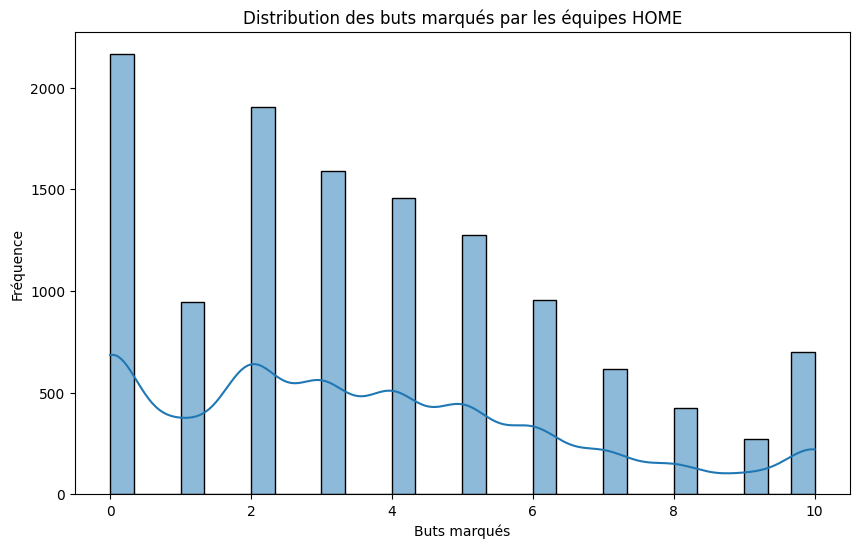

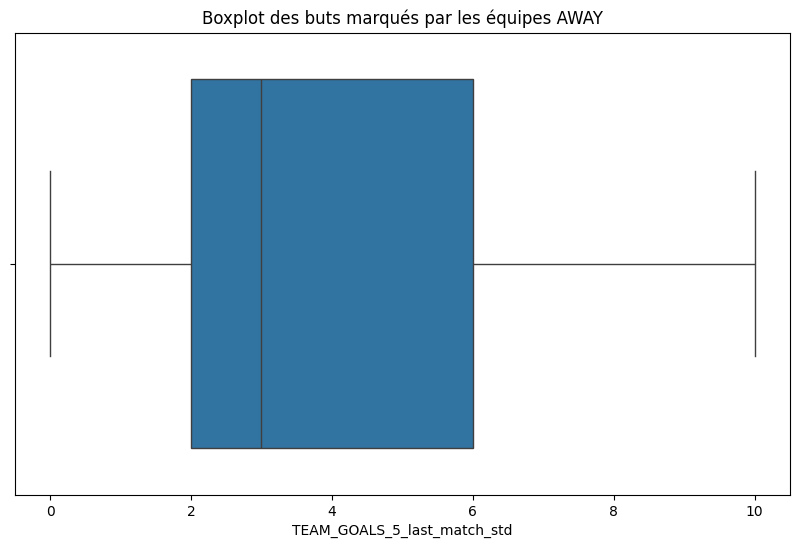

In [37]:
# Histogramme de la variable 'TEAM_GOALS_5_last_match_std'
plt.figure(figsize=(10, 6))
sns.histplot(train_home_team['TEAM_GOALS_5_last_match_std'], kde=True, bins=30)
plt.title('Distribution des buts marqués par les équipes HOME')
plt.xlabel('Buts marqués')
plt.ylabel('Fréquence')
plt.show()

# Boxplot pour détecter des anomalies ( Equipes AWAY )
plt.figure(figsize=(10, 6))
sns.boxplot(x=train_away_team['TEAM_GOALS_5_last_match_std'])
plt.title('Boxplot des buts marqués par les équipes AWAY')
plt.show()


 # 1- Modèle de Clustering des équipes

In [38]:
# Ajouter une colonne pour différencier les contextes HOME et AWAY
train_home_team['CONTEXT'] = 'HOME'
train_away_team['CONTEXT'] = 'AWAY'

In [39]:
# Concaténer les données HOME et AWAY
all_teams = pd.concat([train_home_team, train_away_team], ignore_index=True)

In [40]:

columns_to_use = [
    'TEAM_SHOTS_TOTAL_season_sum',
    'TEAM_PASSES_season_sum',
    'TEAM_SUCCESSFUL_PASSES_season_sum',
    'TEAM_GOALS_5_last_match_std',
    'TEAM_SHOTS_INSIDEBOX_season_sum',

]

In [41]:
# On crée un DataFrame avec les colonnes sélectionnées
team_stats = all_teams[columns_to_use]

In [42]:
# on gére les valeurs manquantes en les remplaçant par la moyenne
team_stats.fillna(team_stats.mean(), inplace=True)

In [43]:
# Standardiser les données pour homogénéiser les métriques
scaler = StandardScaler()
team_stats_scaled = scaler.fit_transform(team_stats)

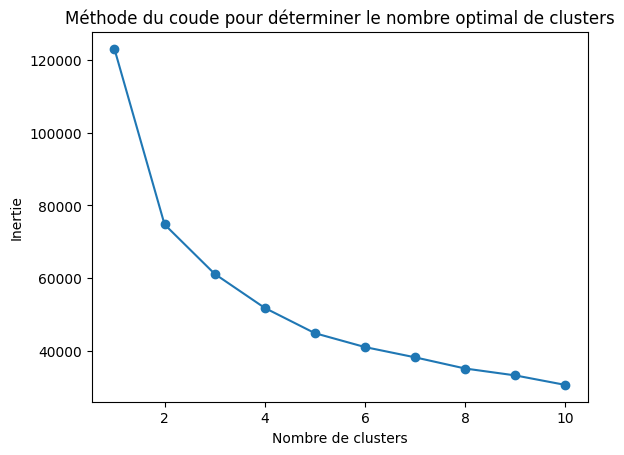

In [44]:
# On déterminer le nombre de clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(team_stats_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Méthode du coude pour déterminer le nombre optimal de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.show()

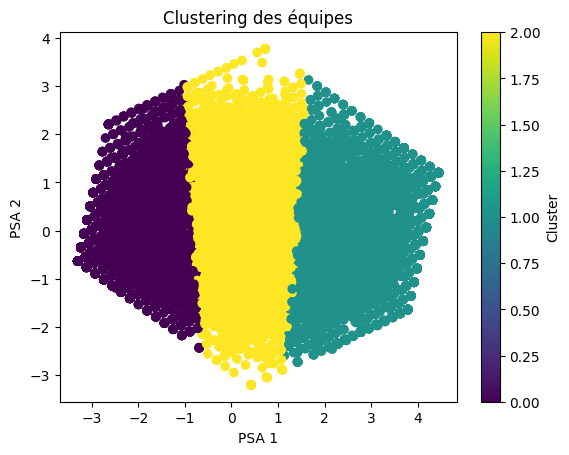

In [46]:
# On applique K-means avec 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(team_stats_scaled)

# on ajoute les clusters au DataFrame original
all_teams['Cluster'] = clusters

pca = PCA(n_components=2)
team_stats_pca = pca.fit_transform(team_stats_scaled)

plt.scatter(team_stats_pca[:, 0], team_stats_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Clustering des équipes')
plt.xlabel('PSA 1')
plt.ylabel('PSA 2')
plt.colorbar(label='Cluster')
plt.show()

L'algorithme de clustering a regroupé les équipes en différentes catégories, visibles sous forme de couleurs distinctes sur le graphique. Chaque point représente une équipe, et la couleur de chaque point correspond à un cluster particulier.
Les résultats montrent comment les équipes se regroupent en fonction de leur performance offensive, ce qui peut aider à identifier des groupes d'équipes avec des styles de jeu ou des stratégies similaires. Ce clustering fournit ainsi des informations utiles pour comprendre les dynamiques entre les équipes, telles que leurs tendances en matière de tirs, de passes et de buts marqués, et peut être utilisé pour affiner les analyses de performance ou de stratégie.

In [48]:

silhouette_avg = silhouette_score(team_stats_scaled, clusters)
print(f"Score de silhouette moyen pour {kmeans.n_clusters} clusters : {silhouette_avg}")


Score de silhouette moyen pour 3 clusters : 0.24579601509247023


Le score de silhouette est calculé pour évaluer la qualité du clustering obtenu avec l'algorithme KMeans. Le score de silhouette mesure à quel point les points d'un cluster sont proches les uns des autres par rapport aux autres clusters. Un score proche de +1 indique un bon clustering, où les points sont bien séparés des autres clusters, tandis qu'un score proche de -1 indique un mauvais clustering, où les points sont mal répartis entre les clusters.

Ici, le score de silhouette moyen pour un clustering avec 3 clusters est de 0.2457. Bien que ce score ne soit pas très élevé, il suggère que les clusters sont relativement séparés, mais qu'il pourrait être possible d'améliorer la qualité du clustering en ajustant le nombre de clusters ou en utilisant d'autres techniques de clustering.

In [49]:

for cluster in range(3):
    print(f"\nÉquipes dans le cluster {cluster}:")
    print(all_teams[all_teams['Cluster'] == cluster][['TEAM_NAME', 'CONTEXT']])


Équipes dans le cluster 0:
               TEAM_NAME CONTEXT
0               Toulouse    HOME
2              Sampdoria    HOME
7               Bordeaux    HOME
10                 Genoa    HOME
11                 Nîmes    HOME
...                  ...     ...
24591  Gimnasia La Plata    AWAY
24592             Huesca    AWAY
24595      VfB Stuttgart    AWAY
24596         Hertha BSC    AWAY
24602           Marítimo    AWAY

[8289 rows x 2 columns]

Équipes dans le cluster 1:
                TEAM_NAME CONTEXT
1                   Brest    HOME
3           Coventry City    HOME
5             Sporting CP    HOME
9       Borussia Dortmund    HOME
18                  Colón    HOME
...                   ...     ...
24577       FC Copenhagen    AWAY
24587              Napoli    AWAY
24597  Arsenal de Sarandi    AWAY
24598               Milan    AWAY
24605        FC Barcelona    AWAY

[5057 rows x 2 columns]

Équipes dans le cluster 2:
                     TEAM_NAME CONTEXT
4      Wolverhampton Wa

Dans l'affichage ci-desuus nous affichons un échantillon des équipes appartenant à chaque cluster. Le code itère sur les clusters et pour chaque cluster, il affiche les équipes qui y appartiennent, ainsi que leur statut de match (HOME ou AWAY). Cela permet d'analyser la répartition des équipes au sein des clusters et d'examiner les équipes qui partagent des caractéristiques similaires, comme leurs performances offensives et défensives.

In [50]:
# on ajoute les clusters aux données originales
cluster_analysis = pd.DataFrame(team_stats, columns=columns_to_use)
cluster_analysis['Cluster'] = clusters

# Analyse des moyennes par cluster
cluster_summary = cluster_analysis.groupby('Cluster').mean()
print("Moyennes par cluster :")
print(cluster_summary)

Moyennes par cluster :
         TEAM_SHOTS_TOTAL_season_sum  TEAM_PASSES_season_sum  \
Cluster                                                        
0                           2.119435                1.893991   
1                           7.788214                8.168677   
2                           4.626562                4.474317   

         TEAM_SUCCESSFUL_PASSES_season_sum  TEAM_GOALS_5_last_match_std  \
Cluster                                                                   
0                                 1.729032                     2.628864   
1                                 7.974095                     4.877330   
2                                 4.197171                     3.864593   

         TEAM_SHOTS_INSIDEBOX_season_sum  
Cluster                                   
0                               1.856222  
1                               7.717093  
2                               4.649338  


Le Cluster 0 regroupe des équipes qui semblent avoir un jeu plutôt équilibré. Elles réalisent un nombre modéré de tirs et de passes, ce qui suggère un style de jeu plus défensif. Ces équipes réussissent aussi un nombre de passes relativement faible. Leur écart-type des buts marqués est également plus bas,ce qui suggère une moindre capacité offensive.

Le Cluster 1 regroupe des équipes plus offensives. Elles se distinguent par un nombre élevé de tirs et de passes réussies. Ces équipes sont aussi plus efficaces dans leurs actions offensives, avec un nombre de buts marqués plus élevé. Ce groupe d'équipes semble être plus dominant offensivement.

Enfin, le Cluster 2 regroupe des équipes dont le style de jeu est plus défensif. Elles réalisent moins de tirs et de passes. Leur nombre de passes réussies est également faible. Cependant, elles semblent concéder moins de buts, avec un écart-type des buts marqués bas.

En résumé, chaque cluster met en évidence un groupe d'équipes avec des caractéristiques de jeu distinctes.

In [51]:

all_teams.to_csv('clusters_teams.csv', index=False)

Étant donné la grande quantité de données, le calcul du dendrogramme pour la Classification Ascendante Hiérarchique (CAH) prenait beaucoup de temps et ne fonctionnait pas efficacement sur l'ensemble complet des données. Pour contourner ce problème j'ai essayé sur un échantillon aléatoire de 1000 équipes choisi d'une manière aléatoire.

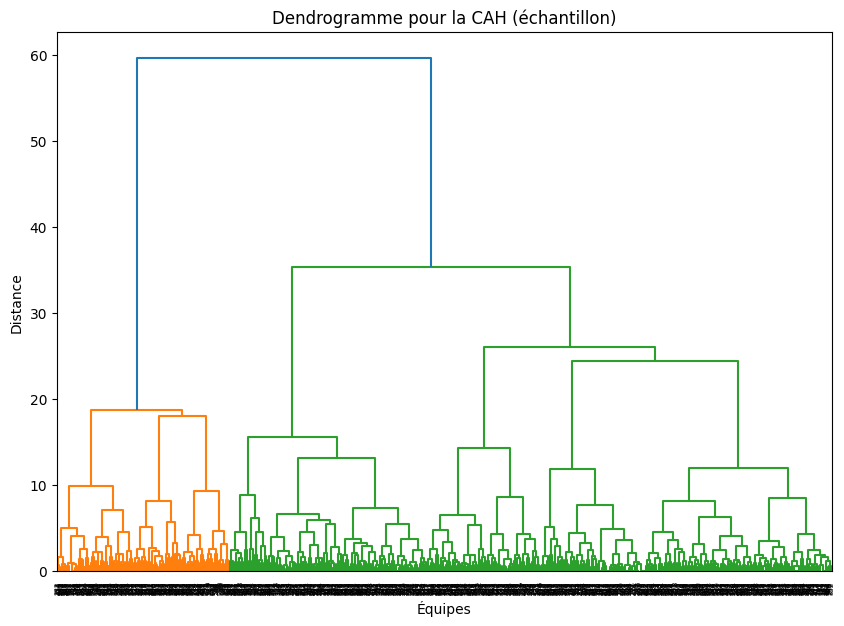

In [52]:
sample_data = team_stats_scaled[np.random.choice(team_stats_scaled.shape[0], 1000, replace=False)]
linkage_matrix = linkage(sample_data, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title("Dendrogramme pour la CAH (échantillon)")
plt.xlabel("Équipes")
plt.ylabel("Distance")
plt.show()


In [53]:

sample_indices = np.random.choice(all_teams.index, size=1000, replace=False)
sample_data = team_stats_scaled[sample_indices]


linkage_matrix = linkage(sample_data, method='ward')
cut_height = 25
cah_clusters = fcluster(linkage_matrix, t=cut_height, criterion='distance')


sample_teams = all_teams.iloc[sample_indices]
sample_teams['CAH_Cluster'] = cah_clusters
print(sample_teams[['CAH_Cluster']].head())


       CAH_Cluster
24545            1
19433            4
24226            3
9702             3
432              2


Tout d'abord, un sous-ensemble de 1000 équipes a été sélectionné aléatoirement à partir de l'ensemble complet des données.
la matrice de distance a été calculée à partir de cet échantillon à l'aide de la méthode de linkage. Le dendrogramme résultant a été coupé à un seuil de distance de 25, afin de former les clusters de manière significative.
Les résultats des clusters ont été ensuite ajoutés à l'échantillon de données, et chaque équipe de l'échantillon a été assignée à un cluster spécifique. La colonne 'CAH_Cluster' a été ajoutée au DataFrame, montrant à quel cluster chaque équipe appartient. L'affichage des premiers résultats montre les équipes et leur assignation à un cluster, avec un total de 4 clusters dans cet échantillon.

In [54]:
print(f"Nombre de clusters : {len(set(cah_clusters))}")


Nombre de clusters : 4


# 2- Modèle de prédiction

# 2-1 Regression linéaire

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer


In [56]:
X_train_home = pd.read_csv('/content/data_train/train_home_team_statistics_df.csv')
X_train_away = pd.read_csv('/content/data_train/train_away_team_statistics_df.csv')
Y_train = pd.read_csv('/content/drive/My Drive/Y_train_1rknArQ.csv')


Dans cette section, j'ai d'abord fusionné les données des équipes HOME et AWAY, car j'ai rencontré un problème de mémoire (RAM) en travaillant directement avec l'ensemble complet des données, incluant les joueurs. Afin d'optimiser l'utilisation de la mémoire, j'ai commencé par fusionner uniquement les données des équipes, ce qui m'a permis de créer un DataFrame plus léger pour l'analyse.

In [57]:

X_train_combined = X_train_home.merge(
    X_train_away,
    on='ID',
    suffixes=('_HOME', '_AWAY')
)

In [58]:

# Création des nouvelles caractéristiques
X_train_combined['GOALS_DIFF'] = X_train_combined['TEAM_GOALS_5_last_match_std_HOME'] - X_train_combined['TEAM_GOALS_5_last_match_std_AWAY']
X_train_combined['SHOTS_DIFF'] = X_train_combined['TEAM_SHOTS_TOTAL_season_sum_HOME'] - X_train_combined['TEAM_SHOTS_TOTAL_season_sum_AWAY']
X_train_combined['SUCCESSFUL_PASSES_DIFF'] = X_train_combined['TEAM_SUCCESSFUL_PASSES_season_sum_HOME'] - X_train_combined['TEAM_SUCCESSFUL_PASSES_season_sum_AWAY']
X_train_combined['ATTACKS_DIFF'] = X_train_combined['TEAM_ATTACKS_5_last_match_std_HOME'] - X_train_combined['TEAM_ATTACKS_5_last_match_std_AWAY']

features = [
    'GOALS_DIFF',
    'SHOTS_DIFF',
    'SUCCESSFUL_PASSES_DIFF',
    'ATTACKS_DIFF',
    'TEAM_GOALS_5_last_match_std_HOME',
    'TEAM_GOALS_5_last_match_std_AWAY',
    'TEAM_SHOTS_TOTAL_season_sum_HOME',
    'TEAM_SHOTS_TOTAL_season_sum_AWAY',
]
X = X_train_combined[features]

Dans la section ci-dessus, de nouvelles caractéristiques ont été créées.
'GOALS_DIFF' : La différence entre les buts marqués lors des 5 derniers matchs HOME et AWAY.
'SHOTS_DIFF' : La différence entre le nombre total de tirs effectués HOME et AWAy
'SUCCESSFUL_PASSES_DIFF' : La différence entre le nombre de passes réussies à HOME et AWAYr.
'ATTACKS_DIFF' : La différence entre le nombre d'attaques réalisées en HOME et AWAY
Ces nouvelles caractéristiques permettent de mieux capturer les différences de performance entre les équipes HOME et AWAY, et sont ensuite utilisées pour la modélisation.

Une fois les caractéristiques créées, j'ai sélectionné un sous-ensemble pertinent de ces colonnes pour l'analyse ainsi que des statistiques supplémentaires comme les buts marqués lors des 5 derniers matchs, le total des tirs et le nombre de passes réussies.

In [59]:
# Imputer les valeurs manquantes avec la moyenne
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [77]:
# Préparation de la variable cible (HOME_WINS, DRAW, AWAY_WINS)
y = Y_train[['HOME_WINS', 'DRAW', 'AWAY_WINS']].idxmax(axis=1)

# Remplacer les catégories par des valeurs numériques
y = y.map({'HOME_WINS': 1, 'DRAW': 0, 'AWAY_WINS': -1})

# Diviser les données en ensemble d'entraînement et de validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Entraîner le modèle de régression linéaire
linreg_model = LinearRegression()
linreg_model.fit(X_train_split, y_train_split)

# Prédictions
y_pred = linreg_model.predict(X_val_split)

# Convertir les prédictions continues en classes
y_pred_classes = np.where(y_pred > 0, 1, np.where(y_pred == 0, 0, -1))


On prépare d'abord la variable cible (le résultat du match) en remplaçant les catégories 'HOME_WINS', 'DRAW', et 'AWAY_WINS' par des valeurs numériques. Ce remplacement est essentiel pour permettre à la régression linéaire de fonctionner correctement, car elle nécessite des valeurs numériques pour la modélisation.
Ensuite, les données sont divisées en ensemble d'entraînement et ensemble de validation, ce qui permet d'évaluer la performance du modèle sur des données non utilisées pour l'entraînement.

Un modèle de régression linéaire est ensuite créé et entraîné sur les données d'entraînement (X_train_split, y_train_split). Une fois le modèle entraîné, il effectue des prédictions sur les données de validation (X_val_split).

Enfin, les prédictions continues obtenues sont converties en classes (résultats de match) en utilisant un seuil. Si la prédiction est supérieure à 0, elle est interprétée comme une victoire HOME (1), si elle est égale à 0, cela représente un match nul (0), et si elle est inférieure à 0, cela signifie une victoire à AWAY (-1).

In [78]:

accuracy = accuracy_score(y_val_split, y_pred_classes)
print(f"Accuracy du modèle : {accuracy:.4f}")


Accuracy du modèle : 0.4884


l'accuracy du modèle est de 0.4884, ce qui signifie que le modèle a correctement prédit environ 48.84 % des résultats. Ce score est relativement bas, ce qui indique que le modèle pourrait nécessiter des améliorations

In [79]:

print("\nRapport de classification :")
print(classification_report(y_val_split, y_pred_classes))




Rapport de classification :
              precision    recall  f1-score   support

          -1       0.46      0.39      0.42       758
           0       0.00      0.00      0.00       620
           1       0.50      0.84      0.62      1083

    accuracy                           0.49      2461
   macro avg       0.32      0.41      0.35      2461
weighted avg       0.36      0.49      0.41      2461



Pour la classe -1 (victoire AWAY), la précision est de 0.46, ce qui signifie que 46 % des prédictions de victoire à l'extérieur étaient correctes. Cependant, le rappel est plus faible (0.39), indiquant que le modèle a tendance à manquer une proportion importante des matchs à l'extérieur. En revanche, la classe 0 (match nul) a une précision de 0.00, ce qui suggère que le modèle n'a pas réussi à prédire correctement les matchs nuls dans les données de test.
Pour la classe 1 (victoire HOME), le modèle a une précision de 0.50 et un rappel de 0.84, ce qui montre qu'il est relativement performant pour prédire les victoires à domicile, avec un rappel élevé mais une précision modérée.
L'accuracy du modèle est de 0.49, indiquant que le modèle a correctement prédit environ 49 % des résultats des matchs.

In [63]:

mse = mean_squared_error(y_val_split, y_pred)
print(f"Mean Squared Error (MSE) : {mse:.4f}")


Mean Squared Error (MSE) : 0.6753


In [67]:

# submission = pd.DataFrame({'ID': X_test_combined['ID'], 'Prediction': y_test_pred})
# submission.to_csv('predictions.csv', index=False)
# print("Les prédictions ont été sauvegardées dans le fichier 'predictions.csv'.")


In [68]:
from google.colab import files
files.download('predictions.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
predictions = pd.read_csv('/content/drive/My Drive/predictions.csv')
output_columns = ['HOME_WINS', 'DRAW', 'AWAY_WINS']

def convert_to_vector(pred):
    if pred == 1:
        return [1, 0, 0]  # HOME_WINS
    elif pred == 0:
        return [0, 1, 0]  # DRAW
    elif pred == -1:
        return [0, 0, 1]  # AWAY_WINS
    else:
        return [0, 0, 0]  # Cas inattendu

predictions[output_columns] = predictions['Prediction'].apply(convert_to_vector).apply(pd.Series)
predictions.drop(columns=['Prediction'], inplace=True)

predictions.to_csv('/content/drive/My Drive/y_teest.csv', index=False)
print(predictions.head())


      ID  HOME_WINS  DRAW  AWAY_WINS
0  12303          1     0          0
1  12304          0     0          1
2  12305          0     1          0
3  12306          0     1          0
4  12307          0     1          0
